# 《LangChain Tool工具调用实验》

## 一、实验目的
1. 理解大语言模型“静态、不可交互”的本质及Tool机制的必要性
2. 理解 Function Calling 的工作原理与调用流程
3. 掌握 LangChain 内置工具（PythonREPLTool）的使用方法
4. 掌握使用 @tool 装饰器和 StructuredTool 两种方式自定义工具
5. 理解大模型自动判断是否调用工具的决策过程
6. 完成天气助手项目实践，综合运用工具调用与链式调用

## 二、实验环境
- 系统：Windows 10
- Python版本：3.10
- 虚拟环境：Miniconda
- 开发工具：VS Code / Jupyter Notebook
- 依赖库：langchain、langchain-core、langchain-deepseek、langchain-experimental、langchain-community、python-dotenv、loguru、httpx
- 模型：DeepSeek（deepseek-chat）


## 三、实验原理

### 3.1 为什么需要Tool

虽然大模型具备强大的语言理解和生成能力，但它本质上是静态的、不可交互的。比如：
* 不具备访问数据库、调用 API 的能力
* 不能执行代码或文件操作
* 无法实时访问互联网或动态数据等

通过 Tool（工具）机制，可以让模型具备“调用外部函数”的能力，使其能够与外部系统、API 或自定义函数交互，从而完成仅靠文本生成无法实现的任务。例如：

* 实时访问外部世界（如天气、股票、网页等）
* 调用计算函数（数学、单位换算）
* 查询数据库或搜索文档
* 实现“多轮决策”流程（如规划任务、搜索后总结）

### 3.2 Function Calling介绍

Function Calling 最早是 OpenAI 在其 API 中引入的一项功能，允许开发者将大语言模型与外部函数或工具集成。通过 Function Calling，模型可以理解用户请求并生成调用外部函数所需的参数，从而实现更复杂、更动态的任务处理。

简单来说，Function calling让大语言模型拥有了调用外部接口的能力，使用这种能力，大模型能做一些比如实时获取天气信息、发送邮件等和现实世界交互的事情。

### Function calling 原理

在发送信息给大模型的时候，携带着“工具”列表，这些工具列表代表着大模型能使用的工具。当大模型遇到用户提出的问题时，会先思考是否应该调用工具解决问题，如果需要调用工具，和普通消息不同，这种情况下会返回“function_call”类型的消息，请求方根据返回结果调用对应的工具得到工具输出，然后将之前的信息加上工具输出的信息一起发送给大模型，让大模型整合起来综合判断给出结果。

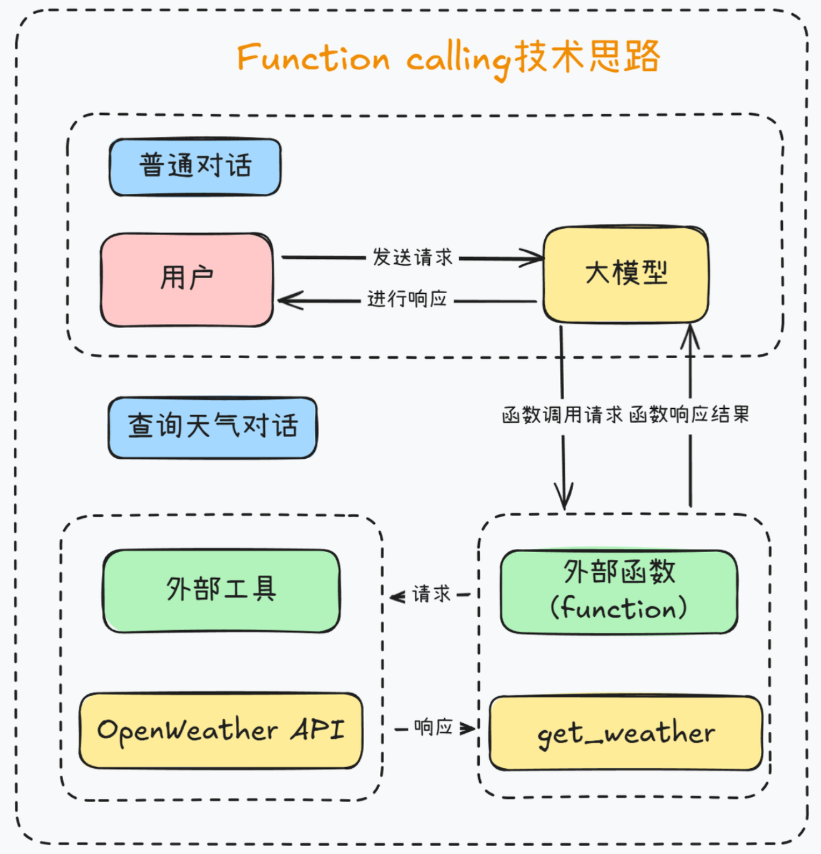

### 3.3 Tool工作原理

工具的工作流程如下：

* 定义工具：指定工具的名称、描述和执行逻辑（函数或类）。
* 注册工具：将工具提供给代理或链，代理根据任务描述选择工具。
* 调用工具：代理生成工具调用的指令（包括输入参数），工具执行并返回结果。
* 处理结果：代理或链将工具输出整合到工作流中，生成最终响应。

工具的核心依赖：

* 工具描述：帮助代理理解工具的功能和适用场景。
* 输入解析：确保工具能正确处理代理提供的输入。
* 输出格式：工具返回的结果应与代理或链的期望兼容。

### 3.4 自定义Tool

Tool 工具机制的思想比较简单，它允许用户以API接口的形式给大模型提供额外的帮助。当本地应用跟大模型聊天时，除了告诉大模型问题，同时也告诉他本地应用能够提供哪些工具。这样大模型会对问题进行综合判断，当觉得需要使用某些工具帮助解决问题时，就会向本地应用返回一个需要调用工具的请求。然后本地应用就可以执行工具，并将工具的执行结果返回给大模型。大模型再结合工具的执行结果，给出一个完整的答案。

### 自定义 Tool 方式

第1种：使用@tool装饰器（自定义工具的最简单方式）

装饰器默认使用函数名称作为工具名称，但可以通过参数name_or_callable来覆盖此设置。同时，装饰器将使用函数的文档字符串作为工具的描述，因此函数必须提供文档字符串。

第2种：使用StructuredTool.from_function类方法

这类似于@tool装饰器，但允许更多配置和同步/异步实现的规范。

### Tool 常用属性

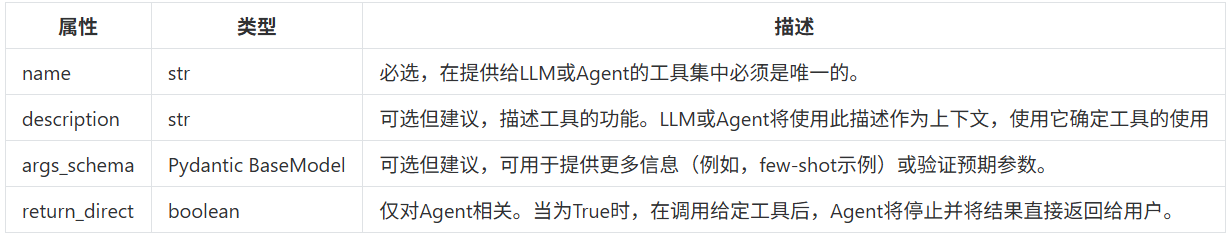

## 四、实验内容

### 4.1 环境准备

安装依赖库并配置环境变量。

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

### 4.2 使用内置Tool（PythonREPLTool）

LangChain提供了多种内置工具，大致可分为以下几类：

1. 搜索工具：如Google搜索、维基百科搜索等
2. 数据库工具：SQL查询、向量数据库操作等
3. API工具：与外部API交互的工具
4. 文件工具：读写文件、处理文档等
5. 数学工具：执行数学计算的工具
6. 编程工具：执行代码、Shell命令等

下面用 LangChain官方内置 PythonREPLTool 实现基于大语言模型的代码生成和执行系统。

In [ ]:
%pip install langchain-experimental==0.4.1 loguru==0.7.3

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_experimental.utilities import PythonREPL
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from loguru import logger
from langchain_deepseek import ChatDeepSeek


def debug_print(x):
    logger.info(f"中间结果:{x}")
    return x


tool = PythonREPL()

llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key,)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "你只返回纯净的 Python 代码，不要解释。代码必须是单行或多行 print。"),
        ("human", "{question}")
    ]
)

debug_node = RunnableLambda(debug_print)
parser = StrOutputParser()

chain = prompt | llm | debug_node | parser | RunnableLambda(lambda code: tool.run(code))

result = chain.invoke({"question": "计算1到100的整数总和"})
logger.info(result)

### 4.3 @tool装饰器实现

定义了一个名为add_number的工具函数，用于执行两个整数相加操作。通过@tool装饰器将函数注册为LangChain工具，绑定参数schema。

In [ ]:
from langchain_core.tools import tool
from loguru import logger
from pydantic import BaseModel, Field


class FieldInfo(BaseModel):
    a: int = Field(description="第1个参数")
    b: int = Field(description="第2个参数")


@tool(args_schema=FieldInfo)
def add_number(a: int, b: int) -> int:
    """
    两个整数相加
    """
    return a + b


logger.info(f"name = {add_number.name}")
logger.info(f"args = {add_number.args}")
logger.info(f"description = {add_number.description}")
logger.info(f"return_direct = {add_number.return_direct}")

res = add_number.invoke({"a": 1, "b": 2})
logger.info(res)

### 4.4 StructuredTool实现

StructuredTool.from_function 类方法提供了比@tool装饰器更多的可配置性，而无需太多额外的代码。

In [ ]:
from langchain_core.tools import StructuredTool
from loguru import logger
from pydantic import BaseModel, Field


class FieldInfo(BaseModel):
    a: int = Field(description="第1个参数")
    b: int = Field(description="第2个参数")


def add_number(a: int, b: int) -> int:
    """
    两个整数相加
    """
    return a + b


func = StructuredTool.from_function(
    func=add_number,
    name="Add",
    description="两个整数相加",
    args_schema=FieldInfo
)
logger.info(f"name = {func.name}")
logger.info(f"description = {func.description}")
logger.info(f"args = {func.args}")

res = func.invoke({"a": 1, "b": 2})
logger.info(res)

### 4.5 调用工具过程使用与分析

大模型会自动分析用户需求，判断是否需要调用指定工具。

如果模型认为需要调用工具，返回的 message 会包含：

- content：通常为空（因为模型选择调用工具，而非生成自然语言回复）
- additional_kwargs：包含工具调用的详细信息

如果模型认为无需调用工具（例如用户输入与工具无关），返回的 message 会是普通文本回复。

In [ ]:
from datetime import date
from langchain_core.tools import tool
from loguru import logger


@tool
def get_today() -> str:
    """
    获取当前系统日期

    Returns:
        str: 今天的日期字符串，格式为 yyyy-MM-dd
    """
    logger.info("执行工具：get_today")
    return date.today().isoformat()


llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

llm_with_tools = llm.bind_tools([get_today])

question_list = ["你是谁？","今天是几号？"]
for question in question_list:
    logger.info(f"用户问题：{question}")
    ai_msg = llm_with_tools.invoke(question)
    logger.info(f"LLM回复：{ai_msg}")
    if ai_msg.tool_calls:
        logger.info(ai_msg.tool_calls)
        tool_call = ai_msg.tool_calls[0]
        tool_result = locals()[tool_call["name"]].invoke(tool_call["args"])
        logger.info(f"调用工具结果：{tool_result}")
    else:
        logger.info(f"LLM 直接作答：{ai_msg.content}")

### 4.6 项目实践：天气助手开发

实现了一个天气查询功能。通过调用OpenWeather API获取指定城市的实时天气数据，并将结果以自然语言形式输出。

#### 获取 API Key

登录https://home.openweathermap.org/api_keys，免费获取API Key，并写入.env文件中。

In [ ]:
# cat .env
OPENWEATHER_API_KEY="XXXX"

#### 定义 Tool 并调用

在 main.py 中引入 tool 与天气助手 API Key，并通过大模型调用 tool。

In [ ]:
%pip install pyowm==3.5.0

In [ ]:
from langchain_core.tools import tool
import json
import os
import httpx

from dotenv import load_dotenv
load_dotenv(override=True)

openweather_api_key = os.getenv("OPENWEATHER_API_KEY")

@tool
def get_weather(loc):
    """
    查询即时天气函数

    :param loc: 必要参数，字符串类型，用于表示查询天气的具体城市名称。
                注意，中国的城市需要用对应城市的英文名称代替，例如如果需要查询北京市天气，
                则 loc 参数需要输入 'Beijing'。
    :return: OpenWeather API 查询即时天气的结果。
    """
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": loc,
        "appid": openweather_api_key,
        "units": "metric",
        "lang": "zh_cn"
    }
    response = httpx.get(url, params=params)
    data = response.json()
    return json.dumps(data)

import dotenv
from langchain_core.output_parsers import JsonOutputKeyToolsParser, StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model
from loguru import logger

dotenv.load_dotenv()

llm = init_chat_model(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

llm_with_tools = llm.bind_tools([get_weather])
parser = JsonOutputKeyToolsParser(key_name=get_weather.name, first_tool_only=True)
get_weather_chain = llm_with_tools | parser | get_weather

output_prompt = PromptTemplate.from_template(
    """你将收到一段 JSON 格式的天气数据{weather_json}，请用简洁自然的方式将其转述给用户。
    以下是天气 JSON 数据：
    请将其转换为中文天气描述。"""
)

output_parser = StrOutputParser()
output_chain = output_prompt | llm | output_parser
full_chain = get_weather_chain | (lambda x: {"weather_json": x}) | output_chain

logger.info("AI 开始流式输出：")
final_result = ""
for chunk in full_chain.stream("请问上海今天的天气如何？"):
    final_result += chunk
    print(chunk, end="", flush=True)
logger.info("\nAI 输出结束")

## 五、实验总结

1. 理解了大语言模型“静态、不可交互”的本质，认识到Tool机制在扩展模型能力上的关键作用
2. 通过 Function Calling 原理学习，掌握了模型判断是否调用工具的决策流程
3. 使用 PythonREPLTool 内置工具实现了代码生成与自动执行的链式调用
4. 通过 @tool 装饰器和 StructuredTool 两种方式自定义工具，对比了两者的配置灵活度
5. 通过 bind_tools 将工具绑定到模型，体验了大模型自动判断是否调用工具的过程
6. 完成天气助手项目实践，综合运用了工具调用、链式调用和流式输出